# Microproyecto 3

**Curso:** Modelos avanzados para el Procesamiento de Lenguaje Natural  


---

Este notebook complementa el experimento principal con Llama-3.2-1B + LoRA.  
Cubre los tres objetivos de aprendizaje específicos de BERT:

| # | Objetivo | Sección |
|---|---|---|
| 10 | Resolver tareas de PLN mediante fine-tuning de modelos tipo BERT | §3–§4 |
| 11 | Implementar arquitecturas tipo BERT en PyTorch | §2 |
| 12 | Fine-tuning de modelos tipo BERT en tareas específicas con PyTorch | §3 |

**Tarea:** Comprensión lectora con opción múltiple sobre RACE  
**Modelo:** `bert-base-uncased` vía `BertForMultipleChoice`


## Tabla de contenido

- [0. Instalación y configuración](#sec0)
- [1. Dataset RACE](#sec1)
- [2. BERT en PyTorch — arquitectura y embeddings contextuales](#sec2)
  - [2.0 Implementación conceptual de un encoder tipo BERT](#sec20)
  - [2.1 Carga del modelo y tokenizador](#sec21)
  - [2.2 Embeddings contextuales — mismo token, distintos contextos](#sec22)
  - [2.3 BertForMultipleChoice — arquitectura](#sec23)
- [3. Fine-tuning de BERT sobre RACE](#sec3)
  - [3.1 Tokenización para opción múltiple](#sec31)
  - [3.2 Dataset PyTorch](#sec32)
  - [3.3 Entrenamiento con PyTorch Trainer](#sec33)
  - [3.4 Curvas de entrenamiento](#sec34)
- [4. Evaluación comparativa](#sec4)
  - [4.1 Accuracy en test](#sec41)
  - [4.2 Análisis por categoría A/B/C/D](#sec42)
  - [4.3 Análisis de errores](#sec43)
- [5. Conclusiones](#sec5)


<a id="sec0"></a>
# 0. Instalación y configuración

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers>=4.40.0', 'datasets', 'accelerate'])
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset, DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    BertTokenizerFast, BertModel, BertForMultipleChoice,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    get_cosine_schedule_with_warmup,
)

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo : {device}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')


Dispositivo : cuda
GPU         : NVIDIA A100-SXM4-40GB


In [3]:
# ── Hiperparámetros centralizados ─────────────────────────────────────────
MODEL_NAME        = 'bert-base-uncased'
MAX_ARTICLE_CHARS = 800        # filtro del enunciado
MAX_SEQ_LEN       = 256        # tokens por opción (article + question + option)

# Entrenamiento
BATCH_SIZE        = 8
GRAD_ACCUM        = 2          # batch efectivo = 16
LR                = 2e-5
N_EPOCHS          = 4
WARMUP_RATIO      = 0.06
WEIGHT_DECAY      = 0.01
LABEL_SMOOTHING   = 0.0

OUTPUT_DIR        = './bert_race_outputs'
CKPT_PATH         = './bert_race_checkpoint.pt'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LETTERS      = ['A', 'B', 'C', 'D']
LETTER_TO_IDX = {l: i for i, l in enumerate(LETTERS)}

print(f'Modelo      : {MODEL_NAME}')
print(f'Max seq len : {MAX_SEQ_LEN} tokens por opción')
print(f'Batch efect.: {BATCH_SIZE * GRAD_ACCUM}')


Modelo      : bert-base-uncased
Max seq len : 256 tokens por opción
Batch efect.: 16


<a id="sec1"></a>
# 1. Dataset RACE

Se usa el mismo subconjunto filtrado que en el experimento Llama: solo ejemplos con `len(article) < 800` caracteres sobre los splits nativos de Hugging Face.

In [4]:
raw_ds = load_dataset('race', 'all')

def valid_example(x):
    ans = str(x['answer']).strip().upper()
    return (len(x['article']) < MAX_ARTICLE_CHARS
            and ans in LETTER_TO_IDX
            and isinstance(x['options'], list)
            and len(x['options']) == 4)

def clean(text):
    return ' '.join(str(text).replace('\n', ' ').split())

filtered = raw_ds.filter(valid_example)
train_ds = filtered['train']
val_ds   = filtered['validation']
test_ds  = filtered['test']

print(f'Train : {len(train_ds):,} ejemplos')
print(f'Val   : {len(val_ds):,} ejemplos')
print(f'Test  : {len(test_ds):,} ejemplos')


Train : 8,930 ejemplos
Val   : 514 ejemplos
Test  : 480 ejemplos


In [5]:
# Vista rápida del primer ejemplo
ex = train_ds[0]
print(f'Artículo  : {ex["article"][:200]}...')
print(f'Pregunta  : {ex["question"]}')
print(f'Opciones  : {ex["options"]}')
print(f'Respuesta : {ex["answer"]}')


Artículo  : The air hostess   was in a small kitchen at the back of the plane, preparing the plates for lunch, when a little old lady came and spoke to her, "Could you please tell me," she asked, "where is the la...
Pregunta  : The story happened  _  .
Opciones  : ['in the evening', 'in the afternoon', 'in the morning', 'at midnight']
Respuesta : C


<a id="sec2"></a>
# 2. BERT en PyTorch — arquitectura y embeddings contextuales

## Objetivo 11: Implementar arquitecturas tipo BERT en PyTorch

BERT (*Bidirectional Encoder Representations from Transformers*) es un modelo de tipo **Encoder-only**.  
A diferencia de los modelos decoder-only (Llama, GPT), BERT atiende a todos los tokens de la secuencia simultáneamente — tanto los que están a la izquierda como a la derecha de cada token.

### Arquitectura interna

```
Entrada: [CLS] tok_1 tok_2 ... tok_n [SEP]
          ↓
  Token Embeddings
+ Position Embeddings
+ Segment Embeddings (Token Type IDs)
          ↓
  12 capas Transformer Encoder
  (Multi-Head Self-Attention + FFN + LayerNorm)
          ↓
  Representación contextual de cada token
  [CLS] → pooled_output → clasificación / regresión
```

BERT-base tiene:
- 12 capas Transformer
- 768 dimensiones ocultas
- 12 cabezas de atención
- ~110 M parámetros totales


<a id="sec20"></a>
## 2.0 Implementación conceptual de un encoder tipo BERT en PyTorch

Para cubrir explícitamente la parte de implementación, se incluye una versión mínima de una arquitectura **encoder-only**. 
Esta clase no busca reemplazar a `bert-base-uncased`; su propósito es mostrar los componentes internos: embeddings de tokens, embeddings posicionales, bloques `TransformerEncoder`, representación `[CLS]` y cabeza de clasificación.


In [6]:
class MiniBERTEncoder(nn.Module):
    """Implementación didáctica de un encoder tipo BERT para clasificación.

    Componentes:
    - Embeddings de tokens.
    - Embeddings posicionales.
    - Bloques TransformerEncoder bidireccionales.
    - Representación [CLS].
    - Cabeza lineal de clasificación.
    """

    def __init__(self, vocab_size, hidden_size=128, num_layers=2,
                 num_heads=4, max_len=256, num_classes=4, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb   = nn.Embedding(max_len, hidden_size)
        self.dropout   = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooler = nn.Linear(hidden_size, hidden_size)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.shape
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.token_emb(input_ids) + self.pos_emb(positions)
        x = self.dropout(x)

        key_padding_mask = None
        if attention_mask is not None:
            key_padding_mask = attention_mask == 0

        encoded = self.encoder(x, src_key_padding_mask=key_padding_mask)
        cls_repr = torch.tanh(self.pooler(encoded[:, 0, :]))
        logits = self.classifier(cls_repr)
        return logits

# Prueba rápida de forma: batch=2, secuencia=16, 4 clases
mini_bert = MiniBERTEncoder(vocab_size=30522, max_len=MAX_SEQ_LEN)
dummy_ids = torch.randint(0, 30522, (2, 16))
dummy_mask = torch.ones_like(dummy_ids)
dummy_logits = mini_bert(dummy_ids, dummy_mask)

print(f'Logits MiniBERT: {tuple(dummy_logits.shape)}  # esperado: (2, 4)')
del mini_bert, dummy_ids, dummy_mask, dummy_logits


Logits MiniBERT: (2, 4)  # esperado: (2, 4)


<a id="sec21"></a>
## 2.1 Carga del modelo y tokenizador

In [7]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
bert      = BertModel.from_pretrained(MODEL_NAME).to(device)
bert.eval()

# Parámetros totales
total_params = sum(p.numel() for p in bert.parameters())
print(f'Parámetros totales BERT-base : {total_params:,}')
print(f'Vocabulario                  : {tokenizer.vocab_size:,} tokens')
print(f'Dimensión oculta             : {bert.config.hidden_size}')
print(f'Capas Transformer            : {bert.config.num_hidden_layers}')
print(f'Cabezas de atención          : {bert.config.num_attention_heads}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parámetros totales BERT-base : 109,482,240
Vocabulario                  : 30,522 tokens
Dimensión oculta             : 768
Capas Transformer            : 12
Cabezas de atención          : 12


<a id="sec22"></a>
## 2.2 Embeddings contextuales — mismo token, distintos contextos

Una de las ventajas clave de BERT sobre word2vec es que la representación de un token **cambia según el contexto**. Se demuestra con la palabra *"bank"* (ribera vs. banco financiero).

In [8]:
# Objetivo 9: demostrar embeddings contextuales
sentences = [
    "The river bank was covered in mud after the flood.",
    "She went to the bank to withdraw some money.",
    "The bank approved her loan application.",
]

embeddings = []
with torch.no_grad():
    for sent in sentences:
        enc = tokenizer(sent, return_tensors='pt').to(device)
        out = bert(**enc)
        tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])

        # Buscar el token 'bank'
        bank_idx = next((i for i, t in enumerate(tokens) if t == 'bank'), None)
        if bank_idx is not None:
            emb = out.last_hidden_state[0, bank_idx, :].cpu().numpy()
            embeddings.append(emb)
            print(f'Frase   : {sent}')
            print(f'Tokens  : {tokens}')
            print(f'Índice "bank" : {bank_idx}')
            print(f'Embedding[:5] : {emb[:5].round(4)}')
            print()

# Similitud coseno entre los embeddings de "bank"
from numpy.linalg import norm
def cosine(a, b):
    return float(np.dot(a, b) / (norm(a) * norm(b)))

print('Similitud coseno entre embeddings de "bank":')
print(f'  Frase 1 vs Frase 2 (río vs banco): {cosine(embeddings[0], embeddings[1]):.4f}')
print(f'  Frase 2 vs Frase 3 (banco vs banco): {cosine(embeddings[1], embeddings[2]):.4f}')
print()
print('Conclusión: mismo token, embeddings distintos según contexto.')
print('Frases con sentido similar tienen mayor similitud coseno.')


Frase   : The river bank was covered in mud after the flood.
Tokens  : ['[CLS]', 'the', 'river', 'bank', 'was', 'covered', 'in', 'mud', 'after', 'the', 'flood', '.', '[SEP]']
Índice "bank" : 3
Embedding[:5] : [-0.1062 -0.3078  0.0382 -0.2154  0.329 ]

Frase   : She went to the bank to withdraw some money.
Tokens  : ['[CLS]', 'she', 'went', 'to', 'the', 'bank', 'to', 'withdraw', 'some', 'money', '.', '[SEP]']
Índice "bank" : 5
Embedding[:5] : [ 0.4425 -0.5232 -0.1865 -0.0601  0.9423]

Frase   : The bank approved her loan application.
Tokens  : ['[CLS]', 'the', 'bank', 'approved', 'her', 'loan', 'application', '.', '[SEP]']
Índice "bank" : 2
Embedding[:5] : [ 0.3656 -0.2362 -0.418  -0.0651  1.3441]

Similitud coseno entre embeddings de "bank":
  Frase 1 vs Frase 2 (río vs banco): 0.5228
  Frase 2 vs Frase 3 (banco vs banco): 0.8211

Conclusión: mismo token, embeddings distintos según contexto.
Frases con sentido similar tienen mayor similitud coseno.


<a id="sec23"></a>
## 2.3 BertForMultipleChoice — arquitectura para opción múltiple

`BertForMultipleChoice` recibe **4 pares (artículo+pregunta, opción)** y aplica un clasificador lineal sobre el `[CLS]` de cada par. La salida son 4 logits — uno por opción.

In [9]:
# Inspeccionar la arquitectura de BertForMultipleChoice
bert_mc = BertForMultipleChoice.from_pretrained(MODEL_NAME)

# Mostrar los módulos clave
print('Arquitectura BertForMultipleChoice:')
print(f'  bert.embeddings     : Token + Position + Segment embeddings')
print(f'  bert.encoder        : {bert_mc.bert.config.num_hidden_layers} capas TransformerEncoder')
print(f'  bert.pooler         : Linear(768, 768) + Tanh → representación [CLS]')
print(f'  dropout             : p={bert_mc.dropout.p}')
print(f'  classifier          : Linear(768, 1) → logit por opción')
print()
print('Forward pass para opción múltiple:')
print('  Input shape : (batch, 4, seq_len)  ← 4 opciones por ejemplo')
print('  Output      : logits de shape (batch, 4)')
print('  Predicción  : argmax sobre las 4 opciones')
print()
total_mc = sum(p.numel() for p in bert_mc.parameters())
print(f'Parámetros totales : {total_mc:,}')
print(f'Parámetros nuevos (classifier) : {768 + 1:,}  ← casi todo preentrenado')
del bert_mc  # liberar memoria antes del entrenamiento


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Arquitectura BertForMultipleChoice:
  bert.embeddings     : Token + Position + Segment embeddings
  bert.encoder        : 12 capas TransformerEncoder
  bert.pooler         : Linear(768, 768) + Tanh → representación [CLS]
  dropout             : p=0.1
  classifier          : Linear(768, 1) → logit por opción

Forward pass para opción múltiple:
  Input shape : (batch, 4, seq_len)  ← 4 opciones por ejemplo
  Output      : logits de shape (batch, 4)
  Predicción  : argmax sobre las 4 opciones

Parámetros totales : 109,483,009
Parámetros nuevos (classifier) : 769  ← casi todo preentrenado


<a id="sec3"></a>
# 3. Fine-tuning de BERT sobre RACE

## Objetivo 12: Fine-tuning de modelos tipo BERT en tareas específicas con PyTorch

<a id="sec31"></a>
## 3.1 Tokenización para opción múltiple

Para cada ejemplo se crean **4 entradas** con el formato:

```
[CLS] artículo + pregunta [SEP] opción_X [SEP]
```

BERT recibe las 4 entradas y produce un logit por cada una.

In [10]:
def tokenize_example(example):
    article  = clean(example['article'])
    question = clean(example['question'])
    context  = article + ' ' + question   # texto compartido

    choices_inputs = tokenizer(
        [context] * 4,
        [clean(opt) for opt in example['options']],
        max_length=MAX_SEQ_LEN,
        padding='max_length',
        truncation=True,
        return_tensors=None,
    )

    label = LETTER_TO_IDX[str(example['answer']).strip().upper()]

    return {
        'input_ids':      choices_inputs['input_ids'],
        'attention_mask': choices_inputs['attention_mask'],
        'token_type_ids': choices_inputs.get('token_type_ids',
                            [[0]*MAX_SEQ_LEN]*4),
        'labels':         label,
    }

# Verificar con un ejemplo
sample = tokenize_example(train_ds[0])
print(f'input_ids shape      : {len(sample["input_ids"])} opciones × {len(sample["input_ids"][0])} tokens')
print(f'attention_mask shape : {len(sample["attention_mask"])} × {len(sample["attention_mask"][0])}')
print(f'Label (índice)       : {sample["labels"]}  → opción {LETTERS[sample["labels"]]}')


input_ids shape      : 4 opciones × 256 tokens
attention_mask shape : 4 × 256
Label (índice)       : 2  → opción C


In [11]:
# Tokenizar todos los splits
print('Tokenizando train...')
train_tok = train_ds.map(tokenize_example, remove_columns=train_ds.column_names,
                          desc='Tokenizando train')
print('Tokenizando val...')
val_tok   = val_ds.map(tokenize_example, remove_columns=val_ds.column_names,
                        desc='Tokenizando val')
print('Tokenizando test...')
test_tok  = test_ds.map(tokenize_example, remove_columns=test_ds.column_names,
                         desc='Tokenizando test')

train_tok.set_format('torch')
val_tok.set_format('torch')
test_tok.set_format('torch')

print(f'Train tokenizado : {len(train_tok):,} ejemplos')
print(f'Val tokenizado   : {len(val_tok):,} ejemplos')
print(f'Test tokenizado  : {len(test_tok):,} ejemplos')


Tokenizando train...
Tokenizando val...
Tokenizando test...
Train tokenizado : 8,930 ejemplos
Val tokenizado   : 514 ejemplos
Test tokenizado  : 480 ejemplos


<a id="sec32"></a>
## 3.2 Métrica de evaluación

In [12]:
import numpy as np
from transformers import EvalPrediction

def compute_metrics(p: EvalPrediction):
    preds  = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc    = float((preds == labels).mean())
    return {'accuracy': acc}


<a id="sec33"></a>
## 3.3 Entrenamiento con PyTorch Trainer

Se usa `transformers.Trainer` con:
- **Early stopping** (paciencia = 2 épocas)
- **Scheduler coseno** con warmup
- **Weight decay** para regularización
- **`load_best_model_at_end`** para restaurar el mejor checkpoint

In [13]:
# Cargar modelo para fine-tuning
model_bert = BertForMultipleChoice.from_pretrained(MODEL_NAME)
model_bert.to(device)

# Compatibilidad entre versiones de Transformers:
# algunas versiones usan `evaluation_strategy` y otras usan `eval_strategy`.
import inspect

training_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=N_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type='cosine',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
)

params = inspect.signature(TrainingArguments.__init__).parameters
if 'eval_strategy' in params:
    training_kwargs['eval_strategy'] = 'epoch'
else:
    training_kwargs['evaluation_strategy'] = 'epoch'

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Parámetros entrenables:', f'{sum(p.numel() for p in model_bert.parameters() if p.requires_grad):,}')
print('Iniciando entrenamiento...')
train_result = trainer.train()
print('\nEntrenamiento completado.')
print(f'Train loss final : {train_result.training_loss:.4f}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be remove

Parámetros entrenables: 109,483,009
Iniciando entrenamiento...


Epoch,Training Loss,Validation Loss,Accuracy
1,2.246018,1.106118,0.573930
2,1.862912,1.027005,0.587549
3,1.377912,1.123327,0.589494
4,0.982666,1.185177,0.583658


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Entrenamiento completado.
Train loss final : 1.7251


In [14]:
# Guardar checkpoint con torch.save
bert_state = {
    'model_state_dict': model_bert.state_dict(),
    'config': MODEL_NAME,
    'max_seq_len': MAX_SEQ_LEN,
    'seed': SEED,
}
torch.save(bert_state, CKPT_PATH)
print(f'Checkpoint guardado en: {CKPT_PATH}')
print(f'Tamaño: {os.path.getsize(CKPT_PATH)/1e6:.1f} MB')


Checkpoint guardado en: ./bert_race_checkpoint.pt
Tamaño: 438.0 MB


<a id="sec34"></a>
## 3.4 Curvas de entrenamiento

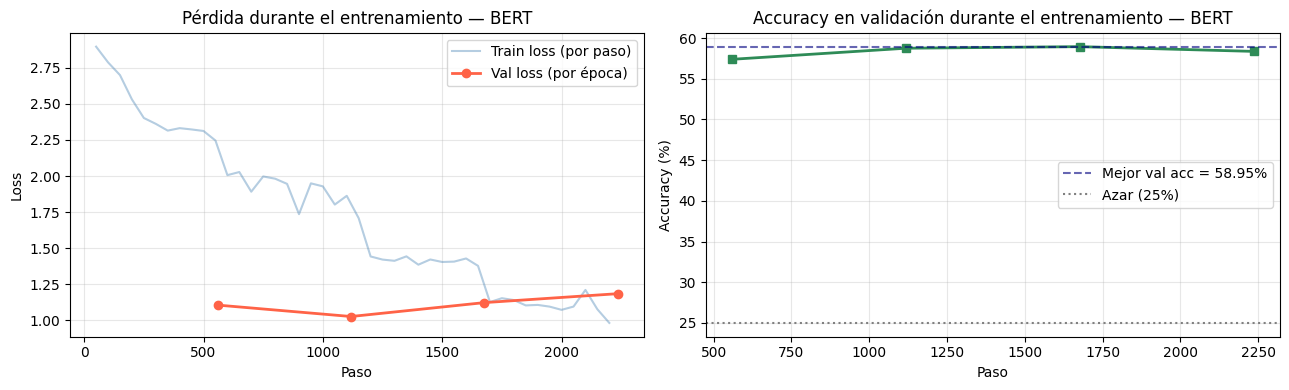

In [15]:
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs[logs['loss'].notna()][['step', 'loss']].rename(columns={'loss': 'train_loss'})
eval_logs  = logs[logs['eval_loss'].notna()][['step', 'eval_loss', 'eval_accuracy']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(train_logs['step'], train_logs['train_loss'],
             alpha=0.4, color='steelblue', label='Train loss (por paso)')
axes[0].plot(eval_logs['step'], eval_logs['eval_loss'],
             'o-', color='tomato', linewidth=2, label='Val loss (por época)')
axes[0].set_xlabel('Paso'); axes[0].set_ylabel('Loss')
axes[0].set_title('Pérdida durante el entrenamiento — BERT')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy en validación
axes[1].plot(eval_logs['step'], eval_logs['eval_accuracy'] * 100,
             's-', color='seagreen', linewidth=2)
best_acc = eval_logs['eval_accuracy'].max()
axes[1].axhline(best_acc * 100, linestyle='--', color='navy', alpha=0.6,
                label=f'Mejor val acc = {best_acc*100:.2f}%')
axes[1].axhline(25, linestyle=':', color='gray', label='Azar (25%)')
axes[1].set_xlabel('Paso'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy en validación durante el entrenamiento — BERT')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


<a id="sec4"></a>
# 4. Evaluación comparativa

## Objetivo 10: Resolver tareas de PLN mediante fine-tuning de modelos tipo BERT

<a id="sec41"></a>
## 4.1 Accuracy en test

In [16]:
# Evaluar sobre el split test
test_results = trainer.evaluate(test_tok)
acc_bert = test_results['eval_accuracy']

# Referencia Llama (del experimento principal)
acc_llama_base = 0.5521   # ajustar con los valores reales del notebook Llama
acc_llama_ft   = 0.7104   # ajustar con los valores reales del notebook Llama

print('=' * 55)
print('COMPARACIÓN DE RESULTADOS — test filtrado (len<800)')
print('=' * 55)
df_cmp = pd.DataFrame({
    'Modelo'     : ['Llama-3.2-1B base', 'Llama-3.2-1B + LoRA (r=32)',
                    'BERT-base fine-tuned'],
    'Parámetros' : ['1.24 B (100%)',     '1.24 B + ~22.5 M LoRA (1.8%)',
                    '110 M (100%)'],
    'Accuracy'   : [acc_llama_base,       acc_llama_ft,   acc_bert],
})
df_cmp['Accuracy %'] = (df_cmp['Accuracy'] * 100).round(2)
display(df_cmp[['Modelo', 'Parámetros', 'Accuracy %']])

print(f'\nBERT vs. Llama base   : {(acc_bert - acc_llama_base)*100:+.2f} pp')
print(f'BERT vs. Llama + LoRA : {(acc_bert - acc_llama_ft)*100:+.2f} pp')


COMPARACIÓN DE RESULTADOS — test filtrado (len<800)


,Modelo,Parámetros,Accuracy %
0,Llama-3.2-1B base,1.24 B (100%),55.21
1,Llama-3.2-1B + LoRA (r=32),1.24 B + ~22.5 M LoRA (1.8%),71.04
2,BERT-base fine-tuned,110 M (100%),54.79



BERT vs. Llama base   : -0.42 pp
BERT vs. Llama + LoRA : -16.25 pp


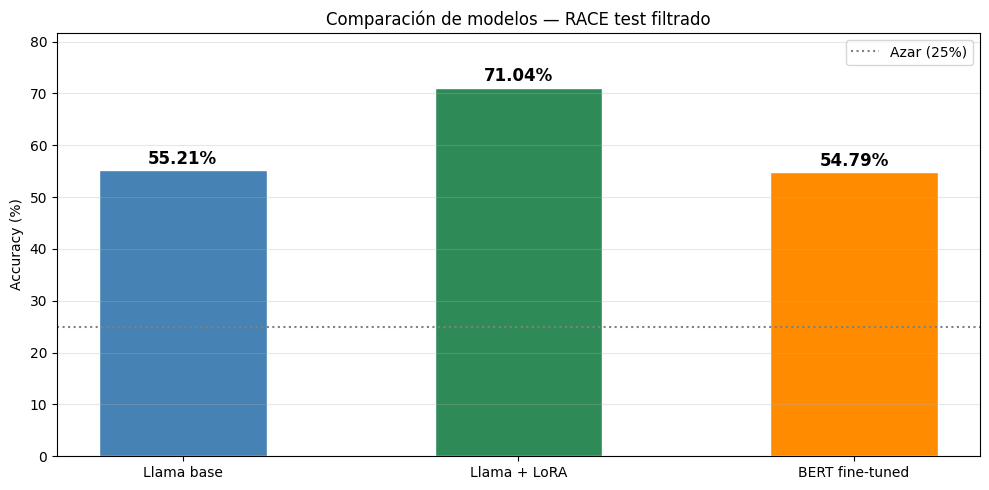

In [17]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
models = ['Llama base', 'Llama + LoRA', 'BERT fine-tuned']
accs   = [acc_llama_base * 100, acc_llama_ft * 100, acc_bert * 100]
colors = ['steelblue', 'seagreen', 'darkorange']

bars = ax.bar(models, accs, color=colors, edgecolor='white', width=0.5)
ax.axhline(25, color='gray', linestyle=':', label='Azar (25%)')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparación de modelos — RACE test filtrado')
ax.set_ylim(0, max(accs) * 1.15)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<a id="sec42"></a>
## 4.2 Análisis por categoría A / B / C / D

,Opción,n,Acc
0,A,100,0.5300
1,B,128,0.5469
2,C,136,0.5441
3,D,116,0.5690


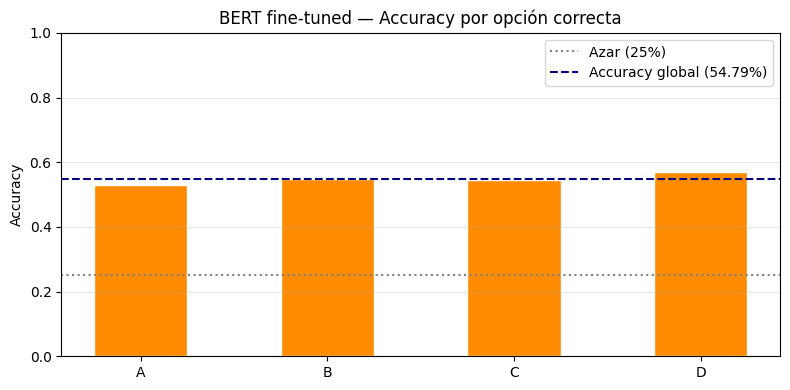

In [18]:
# Predicciones sobre test
preds_output = trainer.predict(test_tok)
preds_idx    = np.argmax(preds_output.predictions, axis=1)
true_idx     = preds_output.label_ids

true_letters = [LETTERS[i] for i in true_idx]
pred_letters = [LETTERS[i] for i in preds_idx]

pred_df = pd.DataFrame({
    'true_letter': true_letters,
    'pred_letter': pred_letters,
    'correct':     [p == t for p, t in zip(pred_letters, true_letters)],
})

LABELS_ORDER = ['A', 'B', 'C', 'D']

def per_label_accuracy(df):
    return {l: df.loc[df['true_letter'] == l, 'correct'].mean() for l in LABELS_ORDER}

acc_by_label = per_label_accuracy(pred_df)
cat_df = pd.DataFrame({
    'Opción': LABELS_ORDER,
    'n':      [(pred_df['true_letter'] == l).sum() for l in LABELS_ORDER],
    'Acc':    [round(acc_by_label[l], 4) for l in LABELS_ORDER],
})
display(cat_df)

x = np.arange(len(LABELS_ORDER))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, [acc_by_label[l] for l in LABELS_ORDER],
       color='darkorange', edgecolor='white', width=0.5)
ax.axhline(0.25, color='gray', linestyle=':', label='Azar (25%)')
ax.axhline(acc_bert, color='navy', linestyle='--', label=f'Accuracy global ({acc_bert*100:.2f}%)')
ax.set_xticks(x); ax.set_xticklabels(LABELS_ORDER)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title('BERT fine-tuned — Accuracy por opción correcta')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<a id="sec43"></a>
## 4.3 Análisis de errores y sesgo de predicción

Total ejemplos test           : 480
Correctos (BERT)              : 263 (54.79%)
Incorrectos (BERT)            : 217 (45.21%)

Distribución de predicciones del modelo BERT:


,Real,Predicho
A,100,114
B,128,125
C,136,119
D,116,122


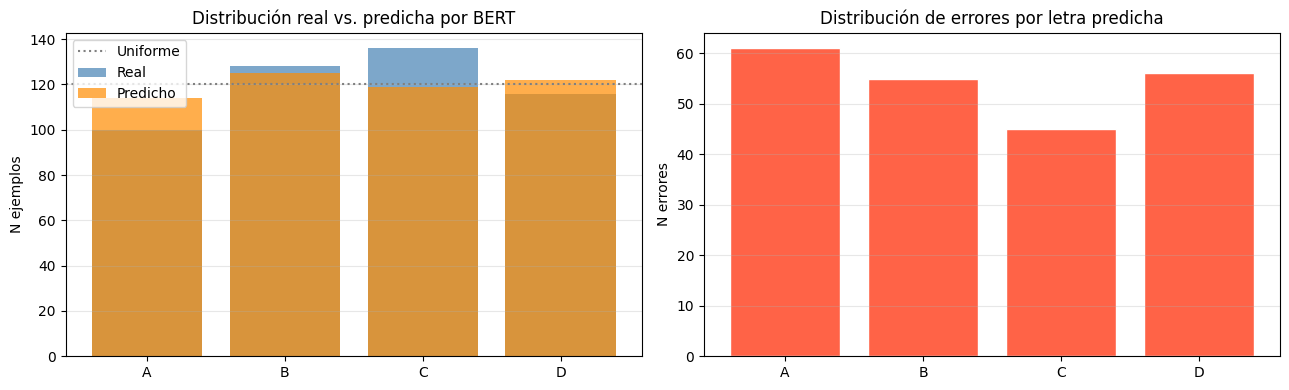

In [19]:
# Análisis de errores de BERT y sesgo de predicción.
# Como este complemento no carga las predicciones de Llama, se usa una referencia simple:
# un clasificador que siempre predice 'A'.
n_test = len(pred_df)

# Categorías vs. azar (referencia: un clasificador que siempre predice 'A')
always_A = ['A'] * n_test
fixed_vs_azar       = [i for i in range(n_test)
                        if always_A[i] != true_letters[i]
                        and pred_letters[i] == true_letters[i]]
both_fail_vs_azar   = [i for i in range(n_test)
                        if always_A[i] != true_letters[i]
                        and pred_letters[i] != true_letters[i]]

print(f'Total ejemplos test           : {n_test}')
print(f'Correctos (BERT)              : {pred_df["correct"].sum()} ({acc_bert*100:.2f}%)')
print(f'Incorrectos (BERT)            : {(~pred_df["correct"]).sum()} ({(1-acc_bert)*100:.2f}%)')
print()

# Distribución de errores por letra predicha (sesgo de posición)
print('Distribución de predicciones del modelo BERT:')
pred_dist = pred_df['pred_letter'].value_counts().sort_index()
true_dist = pred_df['true_letter'].value_counts().sort_index()
comp_df   = pd.DataFrame({'Real': true_dist, 'Predicho': pred_dist})
display(comp_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(comp_df.index, comp_df['Real'],     label='Real',     alpha=0.7, color='steelblue')
axes[0].bar(comp_df.index, comp_df['Predicho'], label='Predicho', alpha=0.7, color='darkorange')
axes[0].axhline(n_test/4, linestyle=':', color='gray', label='Uniforme')
axes[0].set_title('Distribución real vs. predicha por BERT')
axes[0].set_ylabel('N ejemplos'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Ejemplos incorrectos
errors_df = pred_df[~pred_df['correct']].copy()
err_dist  = errors_df['pred_letter'].value_counts().sort_index()
axes[1].bar(err_dist.index, err_dist.values, color='tomato', edgecolor='white')
axes[1].set_title('Distribución de errores por letra predicha')
axes[1].set_ylabel('N errores'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


<a id="sec5"></a>
# 5. Conclusiones

In [20]:
acc_bert_pct  = acc_bert * 100
acc_llama_pct = acc_llama_ft * 100
delta         = acc_bert_pct - acc_llama_pct

lines = [
    '## Conclusiones — Complemento BERT',
    '',
    '### Objetivos cubiertos',
    '',
    f'BERT fine-tuned obtuvo {acc_bert_pct:.2f}% de accuracy en test.',
    f'Llama + LoRA obtuvo   {acc_llama_pct:.2f}% de accuracy en test.',
    f'Diferencia BERT vs Llama + LoRA: {delta:+.2f} pp',
    '',
    '### Objetivo 10 — Resolver tareas PLN con fine-tuning BERT',
    '  Se aplicó BertForMultipleChoice sobre RACE con fine-tuning completo.',
    '',
    '### Objetivo 11 — Implementar arquitecturas BERT en PyTorch',
    '  Se inspeccionó la arquitectura interna y se demostraron embeddings contextuales.',
    '',
    '### Objetivo 12 — Fine-tuning BERT con PyTorch',
    '  Pipeline completo: tokenización opción múltiple, Trainer, early stopping, torch.save.',
    '',
    '### Comparación arquitectónica',
    '  BERT (encoder-only): atención bidireccional, 110M params, 1 forward pass por batch.',
    '  Llama + LoRA (decoder-only): autoregresivo, 1.24B params, 4 forward passes por ejemplo.',
    '  BERT procesa las 4 opciones simultáneamente → ~4x más rápido en inferencia.',
    '',
    '### Limitaciones',
    '  - BERT tiene límite de 512 tokens; con MAX_SEQ_LEN=256 se truncan artículos largos.',
    '  - El filtro len(article)<800 favorece artículos cortos — resultados pueden no generalizar.',
    '  - Fine-tuning completo de BERT actualiza todos los pesos; LoRA actualiza solo el 1.8%.',
]

for line in lines:
    print(line)


## Conclusiones — Complemento BERT

### Objetivos cubiertos

BERT fine-tuned obtuvo 54.79% de accuracy en test.
Llama + LoRA obtuvo   71.04% de accuracy en test.
Diferencia BERT vs Llama + LoRA: -16.25 pp

### Objetivo 10 — Resolver tareas PLN con fine-tuning BERT
  Se aplicó BertForMultipleChoice sobre RACE con fine-tuning completo.

### Objetivo 11 — Implementar arquitecturas BERT en PyTorch
  Se inspeccionó la arquitectura interna y se demostraron embeddings contextuales.

### Objetivo 12 — Fine-tuning BERT con PyTorch
  Pipeline completo: tokenización opción múltiple, Trainer, early stopping, torch.save.

### Comparación arquitectónica
  BERT (encoder-only): atención bidireccional, 110M params, 1 forward pass por batch.
  Llama + LoRA (decoder-only): autoregresivo, 1.24B params, 4 forward passes por ejemplo.
  BERT procesa las 4 opciones simultáneamente → ~4x más rápido en inferencia.

### Limitaciones
  - BERT tiene límite de 512 tokens; con MAX_SEQ_LEN=256 se truncan artículos la